/var/folders/xx/lz1tb24d0y306cdbdfblscxm0000gn/T/ipykernel_59339/1352.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


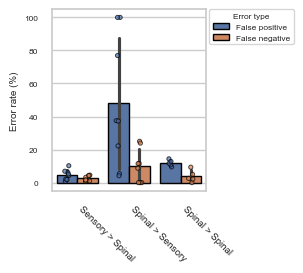

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def frac(num, den):
    if den == 0:
        return 0.0 if num == 0 else np.nan
    return float(num) / float(den)

data = {
    "Sensory axodendritic": {
        "False positive": [
            frac(1,127), frac(9,146), frac(9,210), frac(2,93),
            frac(8,154), frac(6,322), frac(10,145), frac(14,137),
        ],
        "False negative": [
            frac(6,132), frac(6,143), frac(2,203), frac(3,94),
            frac(1,147), frac(14,330), frac(2,137), frac(2,125),
        ],
    },
    "Sensory axoaxonic": {
        "False positive": [
            frac(6,27), frac(9,24), frac(2,37), frac(1,24),
            frac(32,32), frac(41,110), frac(27,27), frac(10,13),
        ],
        "False negative": [
            frac(2,23), frac(5,20), frac(11,46), frac(3,26),
            frac(0,0),
            frac(9,78),
            frac(0,0),
            frac(0,3),
        ],
    },
    "Spinal axodendritic": {
        "False positive": [
            frac(19,132), frac(12,126), frac(16,149),
            frac(12,103), frac(10,78),
        ],
        "False negative": [
            frac(0,0),
            frac(3,117), frac(7,140),
            frac(2,93), frac(7,75),
        ],
    },
}

rows = []
for group, metrics in data.items():
    for metric, values in metrics.items():
        for v in values:
            rows.append({
                "Group": group,
                "Metric": metric,
                "Value": v * 100.0
            })

df = pd.DataFrame(rows)

def cm_to_inch(x):
    return x / 2.54

def plot_error_rates(save_svg=None, width_cm=4.0, height_cm=5.0):
    sns.set(style="whitegrid")

    fig, ax = plt.subplots(
        figsize=(cm_to_inch(width_cm), cm_to_inch(height_cm))
    )

    group_order = [
        "Sensory axodendritic",
        "Sensory axoaxonic",
        "Spinal axodendritic"
    ]
    metric_order = ["False positive", "False negative"]

    sns.barplot(
        data=df,
        x="Group",
        y="Value",
        hue="Metric",
        order=group_order,
        hue_order=metric_order,
        estimator=np.mean,
        errorbar="sd",
        edgecolor="black",
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x="Group",
        y="Value",
        hue="Metric",
        order=group_order,
        hue_order=metric_order,
        dodge=True,
        linewidth=0.7,
        edgecolor="black",
        alpha=0.7,
        size=3,
        ax=ax,
    )

    # Replace x-axis labels
    ax.set_xticklabels([
        "Sensory > Spinal",
        "Spinal > Sensory",
        "Spinal > Spinal",
    ])

    # Legend
    handles, labels = ax.get_legend_handles_labels()
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

    legend = ax.legend(
        handles[:2],
        labels[:2],
        title="Error type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.,
        prop={"size": 6},
    )
    legend.get_title().set_fontsize(6)

    # Axis labels
    ax.set_ylabel("Error rate (%)", fontsize=7)
    ax.set_xlabel("", fontsize=7)
    ax.tick_params(axis="both", which="major", labelsize=7)

    # <-- ONLY CHANGE HERE
    plt.setp(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=7)

    plt.setp(ax.get_yticklabels(), fontsize=6)

    plt.subplots_adjust(right=0.78)

    if save_svg is not None:
        fig.savefig(save_svg, format="svg", bbox_inches="tight")

    plt.show()


# Example
plot_error_rates(
    width_cm=6,
    height_cm=6,
 #   save_svg="synapse_prediction_accuracy.svg",
)

In [2]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Precision / Recall (exclude axoaxonic synapses)
# ------------------------------------------------------------

data_counts = {
    "Sensory axodendritic": {
        "FP": [(1,127), (9,146), (9,210), (2,93),
               (8,154), (6,322), (10,145), (14,137)],
        "FN": [(6,132), (6,143), (2,203), (3,94),
               (1,147), (14,330), (2,137), (2,125)],
    },
    "Spinal axodendritic": {
        "FP": [(19,132), (12,126), (16,149),
               (12,103), (10,78)],
        "FN": [(0,0),
               (3,117), (7,140),
               (2,93), (7,75)],
    },
}

rows = []

for group, d in data_counts.items():

    # ---------- pooled statistics ----------
    fp_errors = sum(x for x, n in d["FP"])
    fp_total  = sum(n for x, n in d["FP"])

    fn_errors = sum(x for x, n in d["FN"])
    fn_total  = sum(n for x, n in d["FN"])

    pooled_precision = 100 * (1 - fp_errors / fp_total)
    pooled_recall    = 100 * (1 - fn_errors / fn_total)

    # ---------- mean across datasets ----------
    precision_each = [
        100 * (1 - x / n)
        for x, n in d["FP"]
        if n > 0
    ]

    recall_each = [
        100 * (1 - x / n)
        for x, n in d["FN"]
        if n > 0
    ]

    rows.append({
        "Group": group,
        "Pooled precision (%)": pooled_precision,
        "Mean precision (%)": np.mean(precision_each),
        "Precision SD": np.std(precision_each, ddof=1),
        "Pooled recall (%)": pooled_recall,
        "Mean recall (%)": np.mean(recall_each),
        "Recall SD": np.std(recall_each, ddof=1),
    })

summary = pd.DataFrame(rows)
pd.set_option("display.precision", 2)

print(summary)

                  Group  Pooled precision (%)  Mean precision (%)  \
0  Sensory axodendritic                 95.58               95.30   
1   Spinal axodendritic                 88.27               88.17   

   Precision SD  Pooled recall (%)  Mean recall (%)  Recall SD  
0          3.11              97.25            97.39        1.6  
1          1.88              95.53            95.24        3.3  


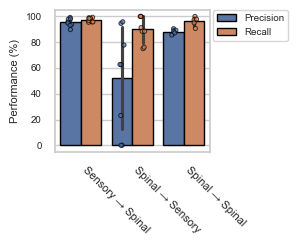

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"   # keep text editable in Illustrator
def frac(num, den):
    if den == 0:
        return 0.0 if num == 0 else np.nan
    return float(num) / float(den)

data = {
    "Sensory → Spinal": {
        "Precision": [
            1-frac(1,127), 1-frac(9,146), 1-frac(9,210), 1-frac(2,93),
            1-frac(8,154), 1-frac(6,322), 1-frac(10,145), 1-frac(14,137),
        ],
        "Recall": [
            1-frac(6,132), 1-frac(6,143), 1-frac(2,203), 1-frac(3,94),
            1-frac(1,147), 1-frac(14,330), 1-frac(2,137), 1-frac(2,125),
        ],
    },
    "Spinal → Sensory": {
        "Precision": [
            1-frac(6,27), 1-frac(9,24), 1-frac(2,37), 1-frac(1,24),
            1-frac(32,32), 1-frac(41,110), 1-frac(27,27), 1-frac(10,13),
        ],
        "Recall": [
            1-frac(2,23), 1-frac(5,20), 1-frac(11,46), 1-frac(3,26),
            1-frac(0,0),
            1-frac(9,78),
            1-frac(0,0),
            1-frac(0,3),
        ],
    },
    "Spinal → Spinal": {
        "Precision": [
            1-frac(19,132), 1-frac(12,126), 1-frac(16,149),
            1-frac(12,103), 1-frac(10,78),
        ],
        "Recall": [
            1-frac(0,0),
            1-frac(3,117), 1-frac(7,140),
            1-frac(2,93), 1-frac(7,75),
        ],
    },
}

rows = []
for group, metrics in data.items():
    for metric, values in metrics.items():
        for v in values:
            rows.append({
                "Group": group,
                "Metric": metric,
                "Value": v * 100
            })

df = pd.DataFrame(rows)

def cm_to_inch(x):
    return x / 2.54

def plot_performance(width_cm=6, height_cm=6, save_svg=None):
    sns.set(style="whitegrid")

    fig, ax = plt.subplots(
        figsize=(cm_to_inch(width_cm), cm_to_inch(height_cm))
    )

    group_order = [
        "Sensory → Spinal",
        "Spinal → Sensory",
        "Spinal → Spinal",
    ]

    metric_order = ["Precision", "Recall"]

    sns.barplot(
        data=df,
        x="Group",
        y="Value",
        hue="Metric",
        order=group_order,
        hue_order=metric_order,
        estimator=np.mean,
        errorbar="sd",
        edgecolor="black",
        ax=ax,
    )

    sns.stripplot(
        data=df,
        x="Group",
        y="Value",
        hue="Metric",
        order=group_order,
        hue_order=metric_order,
        dodge=True,
        linewidth=0.7,
        edgecolor="black",
        alpha=0.7,
        size=3,
        ax=ax,
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    legend = ax.legend(
        handles[:2],
        labels[:2],
 #       title="Metric",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.,
        prop={"size": 7},
    )
    legend.get_title().set_fontsize(6)

    ax.set_ylabel("Performance (%)", fontsize=8)
    ax.set_xlabel("")

    # Give 100% dots room above the top border
    ax.set_ylim(-5, 105)
    ax.set_yticks([0, 20, 40, 60, 80, 100])

    plt.setp(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=7)

    plt.subplots_adjust(right=0.78, bottom=0.28)

    if save_svg is not None:
        fig.savefig(save_svg, format="svg", bbox_inches="tight")

    plt.show()

plot_performance(
    width_cm=6,
    height_cm=6,
    save_svg="synapse_prediction_precision_recall.svg",
)